# 09 Knowledge Graph Explainability
Этап 15: candidate-level semantic / explainability layer для top-k shortlist поверх CatBoost predictive core (без обучения, без reranking).

## 1) Imports and config

In [23]:
import json
import importlib

import numpy as np
import pandas as pd

from _shared_notebook_utils import ROOT, RESEARCH_CHECKPOINT_DIR

nx = importlib.import_module("networkx")

RESULTS_DIR = ROOT / "artifacts" / "results" / "knowledge_graph_explainability"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT =", ROOT)
print("RESULTS_DIR =", RESULTS_DIR)

ROOT = C:\Users\Dmitry\code-projects\diploma-crop-rotation
RESULTS_DIR = C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\knowledge_graph_explainability


## 2) Load artifacts
Используем тот же подход, что в 06/07: model registry + baseline checkpoint split.

In [24]:
registry_path = ROOT / "artifacts" / "model_registry.json"
with open(registry_path, "r", encoding="utf-8") as f:
    registry = json.load(f)

active_model = registry["active_model"]
model_entry = registry["models"][active_model]
model_path = ROOT / model_entry["model_path"]
meta_path = ROOT / model_entry["meta_path"]

if not model_path.exists() or not meta_path.exists():
    raise FileNotFoundError(f"Model artifacts missing for active_model={active_model}: {model_path} / {meta_path}")

baseline_dir = RESEARCH_CHECKPOINT_DIR / "baseline"
train_df = pd.read_pickle(baseline_dir / "train_df.pkl")
val_df = pd.read_pickle(baseline_dir / "val_df.pkl")
test_df = pd.read_pickle(baseline_dir / "test_df.pkl")

with open(meta_path, "r", encoding="utf-8") as f:
    model_meta = json.load(f)

catboost_mod = importlib.import_module("catboost")
CatBoostClassifier = catboost_mod.CatBoostClassifier
model = CatBoostClassifier()
model.load_model(model_path.as_posix())

print("active_model =", active_model)
print("Loaded model:", model_path)
print("Loaded split shapes:", train_df.shape, val_df.shape, test_df.shape)

active_model = baseline
Loaded model: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\catboost\baseline\model.cbm
Loaded split shapes: (26957630, 12) (5776566, 12) (5777014, 12)


## 3) Validate required columns

In [25]:
required_train_cols = [
    "CSBID", "target_year",
    "history_1", "history_2", "history_3",
    "target", "STATEFIPS", "CNTYFIPS",
]
missing_train_cols = [c for c in required_train_cols if c not in train_df.columns]
if missing_train_cols:
    raise ValueError(f"Missing required columns in train_df: {missing_train_cols}")

for split_df in [train_df, val_df, test_df]:
    for col in ["history_1", "history_2", "history_3", "target", "STATEFIPS", "CNTYFIPS"]:
        if col in split_df.columns:
            split_df[col] = split_df[col].astype("string")

print("train_df columns validated.")
print("train_df shape =", train_df.shape)
print("val_df shape =", val_df.shape)
print("test_df shape =", test_df.shape)

train_df columns validated.
train_df shape = (26957630, 12)
val_df shape = (5776566, 12)
test_df shape = (5777014, 12)


## 4) Define semantic mappings

In [26]:
CROP_TO_GROUP = {
    "corn": "cereal",
    "wheat": "cereal",
    "sorghum": "cereal",
    "other_cereals": "cereal",
    "soybeans": "legume",
    "legumes": "legume",
    "forage_hay": "forage",
    "cotton": "industrial",
    "fallow": "fallow",
}

crop_group_df = pd.DataFrame([
    {"crop_name": crop, "crop_group": group}
    for crop, group in CROP_TO_GROUP.items()
]).sort_values(["crop_group", "crop_name"]).reset_index(drop=True)

display(crop_group_df)

,crop_name,crop_group
0,corn,cereal
1,other_cereals,cereal
2,sorghum,cereal
3,wheat,cereal
4,fallow,fallow
5,forage_hay,forage
6,cotton,industrial
7,legumes,legume
8,soybeans,legume


## 5) Build knowledge graph nodes

In [27]:
def make_region_id(statefips, cntyfips):
    return f"region_{statefips}_{cntyfips}"

crop_nodes = [
    {
        "node_id": f"crop_{crop}",
        "node_type": "Crop",
        "name": crop,
        "display_name": crop,
        "metadata_json": json.dumps({"crop_group": CROP_TO_GROUP.get(crop)}, ensure_ascii=False),
    }
    for crop in sorted(CROP_TO_GROUP.keys())
]

region_unique = (
    train_df[["STATEFIPS", "CNTYFIPS"]]
    .dropna()
    .astype({"STATEFIPS": "string", "CNTYFIPS": "string"})
    .drop_duplicates()
)
region_nodes = [
    {
        "node_id": make_region_id(row.STATEFIPS, row.CNTYFIPS),
        "node_type": "Region",
        "name": f"{row.STATEFIPS}_{row.CNTYFIPS}",
        "display_name": f"state={row.STATEFIPS}, county={row.CNTYFIPS}",
        "metadata_json": json.dumps({"STATEFIPS": str(row.STATEFIPS), "CNTYFIPS": str(row.CNTYFIPS)}, ensure_ascii=False),
    }
    for row in region_unique.itertuples(index=False)
]

group_nodes = [
    {
        "node_id": f"group_{group}",
        "node_type": "CropGroup",
        "name": group,
        "display_name": group,
        "metadata_json": json.dumps({}, ensure_ascii=False),
    }
    for group in sorted(set(CROP_TO_GROUP.values()))
]

rule_ids = [
    "rule_repeat_crop_penalty",
    "rule_same_group_saturation",
    "rule_legume_break_bonus",
    "rule_fallow_break_effect",
    "rule_region_typicality",
]
rule_nodes = [
    {
        "node_id": rule_id,
        "node_type": "Rule",
        "name": rule_id,
        "display_name": rule_id.replace("rule_", "").replace("_", " ").title(),
        "metadata_json": json.dumps({}, ensure_ascii=False),
    }
    for rule_id in rule_ids
]

nodes_df = pd.DataFrame(crop_nodes + region_nodes + group_nodes + rule_nodes)
nodes_df = nodes_df.drop_duplicates(subset=["node_id"]).reset_index(drop=True)

print("nodes_df shape =", nodes_df.shape)
display(nodes_df["node_type"].value_counts(dropna=False).rename_axis("node_type").reset_index(name="count"))

nodes_df shape = (2827, 5)


,node_type,count
0,Region,2808
1,Crop,9
2,CropGroup,5
3,Rule,5


## 6) Build knowledge graph edges

In [28]:
# 6.1 follows_after (Crop -> Crop), train-only
transition_counts = (
    train_df.groupby(["history_3", "target"], dropna=False)
    .size()
    .rename("transition_count")
    .reset_index()
    .dropna(subset=["history_3", "target"])
    .astype({"history_3": "string", "target": "string"})
)
transition_counts["transition_prob"] = (
    transition_counts["transition_count"]
    / transition_counts.groupby("history_3")["transition_count"].transform("sum")
)

transition_edges_df = transition_counts.rename(columns={"history_3": "last_crop", "target": "candidate"}).copy()
transition_edges_df["source_id"] = "crop_" + transition_edges_df["last_crop"].astype(str)
transition_edges_df["target_id"] = "crop_" + transition_edges_df["candidate"].astype(str)
transition_edges_df["edge_type"] = "follows_after"
transition_edges_df["weight"] = transition_edges_df["transition_prob"].astype(float)
transition_edges_df["support"] = transition_edges_df["transition_count"].astype(int)
transition_edges_df["note"] = "observed train transition"

display(transition_edges_df[["last_crop", "candidate", "transition_prob", "transition_count"]].head(15))

,last_crop,candidate,transition_prob,transition_count
0,corn,corn,0.309146,2459160
1,corn,cotton,0.016765,133363
2,corn,fallow,0.028365,225637
3,corn,forage_hay,0.017276,137429
4,corn,legumes,0.010607,84379
5,corn,other_cereals,0.014181,112804
6,corn,sorghum,0.012758,101485
7,corn,soybeans,0.562229,4472357
8,corn,wheat,0.028672,228075
9,cotton,corn,0.119207,140232


In [29]:
# 6.2 common_in_region (Region -> Crop), train-only
region_counts = (
    train_df.groupby(["STATEFIPS", "CNTYFIPS", "target"], dropna=False)
    .size()
    .rename("region_crop_count")
    .reset_index()
    .dropna(subset=["STATEFIPS", "CNTYFIPS", "target"])
    .astype({"STATEFIPS": "string", "CNTYFIPS": "string", "target": "string"})
)

region_counts["region_crop_share"] = (
    region_counts["region_crop_count"]
    / region_counts.groupby(["STATEFIPS", "CNTYFIPS"])["region_crop_count"].transform("sum")
)
region_counts["rank_in_region"] = region_counts.groupby(["STATEFIPS", "CNTYFIPS"])["region_crop_count"].rank(method="dense", ascending=False)

region_edges_df = region_counts.rename(columns={"target": "candidate"}).copy()
region_edges_df["region_id"] = region_edges_df.apply(lambda r: make_region_id(r["STATEFIPS"], r["CNTYFIPS"]), axis=1)
region_edges_df["source_id"] = region_edges_df["region_id"]
region_edges_df["target_id"] = "crop_" + region_edges_df["candidate"].astype(str)
region_edges_df["edge_type"] = "common_in_region"
region_edges_df["weight"] = region_edges_df["region_crop_share"].astype(float)
region_edges_df["support"] = region_edges_df["region_crop_count"].astype(int)
region_edges_df["note"] = "regional crop prevalence"

display(region_edges_df[["STATEFIPS", "CNTYFIPS", "candidate", "region_crop_share", "rank_in_region"]].head(15))

,STATEFIPS,CNTYFIPS,candidate,region_crop_share,rank_in_region
0,01,001,corn,0.130835,2.0
1,01,001,cotton,0.697313,1.0
2,01,001,fallow,0.000707,8.0
3,01,001,forage_hay,0.099010,3.0
4,01,001,other_cereals,0.002829,7.0
5,01,001,sorghum,0.010608,6.0
6,01,001,soybeans,0.045262,4.0
7,01,001,wheat,0.013437,5.0
8,01,003,corn,0.158481,4.0
9,01,003,cotton,0.234093,2.0


In [30]:
# 6.3 belongs_to_group and rule links
belongs_edges_df = pd.DataFrame([
    {
        "source_id": f"crop_{crop}",
        "target_id": f"group_{group}",
        "edge_type": "belongs_to_group",
        "weight": 1.0,
        "support": np.nan,
        "note": "semantic crop grouping",
    }
    for crop, group in CROP_TO_GROUP.items()
])

all_crops = sorted(CROP_TO_GROUP.keys())
cereal_crops = ["corn", "wheat", "sorghum", "other_cereals"]

rule_links = []

for crop in ["soybeans", "legumes"]:
    rule_links.append({"rule_id": "rule_legume_break_bonus", "crop": crop, "edge_type": "supports_candidate"})
for crop in cereal_crops:
    rule_links.append({"rule_id": "rule_same_group_saturation", "crop": crop, "edge_type": "warns_about_candidate"})
for crop in all_crops:
    rule_links.append({"rule_id": "rule_region_typicality", "crop": crop, "edge_type": "supports_candidate"})
for crop in all_crops:
    rule_links.append({"rule_id": "rule_repeat_crop_warning", "crop": crop, "edge_type": "warns_about_candidate"})
for crop in all_crops:
    if crop == "fallow":
        rule_links.append({"rule_id": "rule_fallow_break_effect", "crop": crop, "edge_type": "warns_about_candidate"})
    else:
        rule_links.append({"rule_id": "rule_fallow_break_effect", "crop": crop, "edge_type": "supports_candidate"})

rule_edges_df = pd.DataFrame(rule_links)
rule_edges_df["source_id"] = rule_edges_df["rule_id"]
rule_edges_df["target_id"] = "crop_" + rule_edges_df["crop"].astype(str)
rule_edges_df["weight"] = 1.0
rule_edges_df["support"] = np.nan
rule_edges_df["note"] = "semantic rule link"

edge_cols = ["source_id", "target_id", "edge_type", "weight", "support", "note"]
edges_df = pd.concat([
    transition_edges_df[edge_cols],
    region_edges_df[edge_cols],
    belongs_edges_df[edge_cols],
    rule_edges_df[edge_cols],
], ignore_index=True)
edges_df = edges_df.drop_duplicates().reset_index(drop=True)

print("edges_df shape =", edges_df.shape)
display(edges_df["edge_type"].value_counts(dropna=False).rename_axis("edge_type").reset_index(name="count"))

edges_df shape = (18154, 6)


,edge_type,count
0,common_in_region,17950
1,follows_after,162
2,supports_candidate,19
3,warns_about_candidate,14
4,belongs_to_group,9


## 7) Build rule layer

In [31]:
rules_df = pd.DataFrame([
    {
        "rule_id": "rule_repeat_crop_warning",
        "rule_name": "repeat_crop_warning",
        "rule_type": "warning",
        "description": "Warning if candidate repeats the last crop.",
        "logic_comment": "candidate == history_3",
    },
    {
        "rule_id": "rule_same_group_saturation",
        "rule_name": "same_group_saturation",
        "rule_type": "warning",
        "description": "Warning when history is group-saturated and candidate stays in same group.",
        "logic_comment": "dominant history group ratio >= 0.67 and candidate group == dominant group",
    },
    {
        "rule_id": "rule_legume_break_bonus",
        "rule_name": "legume_break_bonus",
        "rule_type": "support",
        "description": "May support legume candidates if recent history has no legumes.",
        "logic_comment": "candidate in {soybeans, legumes} and no legume in recent history",
    },
    {
        "rule_id": "rule_fallow_break_effect",
        "rule_name": "fallow_break_effect",
        "rule_type": "support_or_warning",
        "description": "May support return from fallow and may warn on repeated fallow.",
        "logic_comment": "if fallow in history and candidate!=fallow -> support; if candidate==fallow and fallow in history -> warning",
    },
    {
        "rule_id": "rule_region_typicality",
        "rule_name": "region_typicality",
        "rule_type": "support",
        "description": "May support candidates that are typical for the region.",
        "logic_comment": "candidate rank_in_region <= 3 based on train statistics",
    },
])

display(rules_df)

,rule_id,rule_name,rule_type,description,logic_comment
0,rule_repeat_crop_warning,repeat_crop_warning,warning,Warning if candidate repeats the last crop.,candidate == history_3
1,rule_same_group_saturation,same_group_saturation,warning,Warning when history is group-saturated and ca...,dominant history group ratio >= 0.67 and candi...
2,rule_legume_break_bonus,legume_break_bonus,support,May support legume candidates if recent histor...,"candidate in {soybeans, legumes} and no legume..."
3,rule_fallow_break_effect,fallow_break_effect,support_or_warning,May support return from fallow and may warn on...,if fallow in history and candidate!=fallow -> ...
4,rule_region_typicality,region_typicality,support,May support candidates that are typical for th...,candidate rank_in_region <= 3 based on train s...


## 8) Save graph artifacts

In [32]:
nodes_df.to_csv(RESULTS_DIR / "kg_nodes.csv", index=False)
edges_df.to_csv(RESULTS_DIR / "kg_edges.csv", index=False)
rules_df.to_csv(RESULTS_DIR / "kg_rules.csv", index=False)

nodes_df.to_pickle(RESULTS_DIR / "kg_nodes.pkl")
edges_df.to_pickle(RESULTS_DIR / "kg_edges.pkl")
rules_df.to_pickle(RESULTS_DIR / "kg_rules.pkl")

transition_edges_df.to_csv(RESULTS_DIR / "transition_edges.csv", index=False)
region_edges_df.to_csv(RESULTS_DIR / "region_edges.csv", index=False)

print("Saved graph artifacts to:", RESULTS_DIR)

Saved graph artifacts to: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\knowledge_graph_explainability


## 9) Build explainability helpers
`graph_support_score` is a transparent rule-based indicator in `[0, 1]` and is used as an additional explainability signal (not as a new model).

> Formula (clipped to `[0, 1]`):
`score = 0.50 * transition_norm + 0.30 * region_norm + 0.10 * region_rank_norm + 0.04 * n_support - 0.05 * n_warning`

- `transition_norm`: normalized `transition_prob` from train transitions
- `region_norm`: normalized `region_share` in the current region
- `region_rank_norm`: bonus for top regional ranks (rank 1 > rank 2 > rank 3)
- `n_support`: support-rule count (small capped bonus)
- `n_warning`: warning-rule count (small capped penalty)

Level mapping from score:
- `strong`: `score >= 0.66`
- `moderate`: `0.33 <= score < 0.66`
- `weak`: `score < 0.33`

Alignment margin (shortlist level):
- `strong`: top-1 has the highest `graph_support_score`
- `medium`: top-1 is close to best alternative (`delta <= 0.08`)
- `weak`: an alternative has noticeably higher graph support

In [33]:
transition_lookup = {
    (str(r.last_crop), str(r.candidate)): {
        "transition_prob": float(r.transition_prob),
        "transition_support": int(r.transition_count),
    }
    for r in transition_edges_df[["last_crop", "candidate", "transition_prob", "transition_count"]].itertuples(index=False)
}

region_lookup = {
    (str(r.region_id), str(r.candidate)): {
        "region_share": float(r.region_crop_share),
        "region_support": int(r.region_crop_count),
        "region_rank": int(r.rank_in_region),
    }
    for r in region_edges_df[["region_id", "candidate", "region_crop_share", "region_crop_count", "rank_in_region"]].itertuples(index=False)
}

GRAPH_SCORE_WEIGHTS = {
    "transition": 0.50,
    "region_share": 0.30,
    "region_rank": 0.10,
    "support_bonus": 0.04,
    "warning_penalty": 0.05,
}
GRAPH_ALIGNMENT_MARGIN = 0.08

def get_crop_group(crop_name):
    return CROP_TO_GROUP.get(str(crop_name), "unknown")

def get_transition_fact(last_crop, candidate, transition_edges_df):
    _ = transition_edges_df
    return transition_lookup.get((str(last_crop), str(candidate)))

def get_region_fact(statefips, cntyfips, candidate, region_edges_df):
    _ = region_edges_df
    region_id = make_region_id(statefips, cntyfips)
    return region_lookup.get((region_id, str(candidate)))

def evaluate_rules_for_candidate(sample_row, candidate, crop_to_group, region_edges_df):
    support_flags = []
    warning_flags = []

    h1 = str(sample_row.get("history_1", ""))
    h2 = str(sample_row.get("history_2", ""))
    h3 = str(sample_row.get("history_3", ""))
    history = [h1, h2, h3]
    cand = str(candidate)

    if cand == h3:
        warning_flags.append("repeat_crop_warning")

    hist_groups = [crop_to_group.get(c) for c in history if c in crop_to_group]
    if hist_groups:
        group_counts = pd.Series(hist_groups).value_counts()
        dominant_group = str(group_counts.index[0])
        dominant_ratio = float(group_counts.iloc[0] / len(hist_groups))
        if dominant_ratio >= 0.67 and crop_to_group.get(cand) == dominant_group:
            warning_flags.append("same_group_saturation")

    has_legume_recently = any(crop_to_group.get(c) == "legume" for c in history)
    if (not has_legume_recently) and cand in {"soybeans", "legumes"}:
        support_flags.append("legume_break_bonus")

    has_fallow_recently = "fallow" in history
    if has_fallow_recently and cand != "fallow":
        support_flags.append("fallow_break_effect")
    if has_fallow_recently and cand == "fallow":
        warning_flags.append("fallow_break_effect")

    region_fact = get_region_fact(sample_row.get("STATEFIPS"), sample_row.get("CNTYFIPS"), cand, region_edges_df)
    if region_fact is not None and region_fact["region_rank"] <= 3:
        support_flags.append("region_typicality")

    return support_flags, warning_flags

def get_topk_predictions(model, X, class_names, k=3):
    proba = np.asarray(model.predict_proba(X))
    k = min(int(k), proba.shape[1])
    top_idx_unsorted = np.argpartition(proba, -k, axis=1)[:, -k:]
    top_proba_unsorted = np.take_along_axis(proba, top_idx_unsorted, axis=1)
    sort_order = np.argsort(-top_proba_unsorted, axis=1)
    top_idx = np.take_along_axis(top_idx_unsorted, sort_order, axis=1)
    top_scores = np.take_along_axis(top_proba_unsorted, sort_order, axis=1)
    class_arr = np.asarray(class_names, dtype=object)
    top_labels = class_arr[top_idx]
    return top_labels, top_scores

def compute_graph_support_score(transition_prob, region_share, region_rank, support_flags, warning_flags):
    transition_norm = 0.0 if transition_prob is None else float(np.clip(float(transition_prob), 0.0, 1.0))
    region_norm = 0.0 if region_share is None else float(np.clip(float(region_share), 0.0, 1.0))

    if region_rank is None:
        region_rank_norm = 0.0
    else:
        region_rank_norm = float(np.clip((4.0 - float(region_rank)) / 3.0, 0.0, 1.0))

    support_bonus = GRAPH_SCORE_WEIGHTS["support_bonus"] * min(len(support_flags), 3)
    warning_penalty = GRAPH_SCORE_WEIGHTS["warning_penalty"] * min(len(warning_flags), 3)

    score = (
        GRAPH_SCORE_WEIGHTS["transition"] * transition_norm
        + GRAPH_SCORE_WEIGHTS["region_share"] * region_norm
        + GRAPH_SCORE_WEIGHTS["region_rank"] * region_rank_norm
        + support_bonus
        - warning_penalty
    )
    return float(np.clip(score, 0.0, 1.0))

def resolve_graph_support_level(graph_support_score):
    if graph_support_score >= 0.66:
        return "strong"
    if graph_support_score >= 0.33:
        return "moderate"
    return "weak"

def build_candidate_explanations_for_sample(
    sample_row,
    topk_candidates,
    topk_scores,
    transition_edges_df,
    region_edges_df,
    crop_to_group,
    true_target=None,
):
    rows = []
    last_crop = str(sample_row.get("history_3"))
    statefips = sample_row.get("STATEFIPS")
    cntyfips = sample_row.get("CNTYFIPS")
    true_target = None if true_target is None else str(true_target)

    for rank_idx, (cand, score) in enumerate(zip(topk_candidates, topk_scores), start=1):
        cand = str(cand)
        t_fact = get_transition_fact(last_crop, cand, transition_edges_df)
        r_fact = get_region_fact(statefips, cntyfips, cand, region_edges_df)
        support_flags, warning_flags = evaluate_rules_for_candidate(sample_row, cand, crop_to_group, region_edges_df)

        transition_prob = None if t_fact is None else float(t_fact["transition_prob"])
        transition_support = None if t_fact is None else int(t_fact["transition_support"])
        region_share = None if r_fact is None else float(r_fact["region_share"])
        region_rank = None if r_fact is None else int(r_fact["region_rank"])

        repeat_warning_severity = None
        if "repeat_crop_warning" in warning_flags:
            strong_repeat_context = (
                (transition_prob is not None and transition_prob >= 0.35)
                and (
                    (region_share is not None and region_share >= 0.15)
                    or (region_rank is not None and region_rank <= 3)
                )
            )
            repeat_warning_severity = "low" if strong_repeat_context else "medium"

        graph_support_score = compute_graph_support_score(
            transition_prob=transition_prob,
            region_share=region_share,
            region_rank=region_rank,
            support_flags=support_flags,
            warning_flags=warning_flags,
        )
        graph_support_level = resolve_graph_support_level(graph_support_score)

        is_model_top1 = rank_idx == 1
        is_true_target = (true_target is not None) and (cand == true_target)

        if is_true_target and is_model_top1:
            candidate_role = "true_target_top1"
        elif is_true_target:
            candidate_role = "true_target_in_shortlist"
        elif is_model_top1:
            candidate_role = "top1_model_choice"
        else:
            candidate_role = "alternative_candidate"

        phrases = []
        if transition_prob is not None:
            phrases.append(f"Observed transition {last_crop} -> {cand} appears in train data.")
        if region_rank is not None and region_rank <= 3:
            phrases.append("Candidate is common in the current region.")
        phrases.append(f"Candidate belongs to {get_crop_group(cand)} group.")
        if "legume_break_bonus" in support_flags:
            phrases.append("Rule legume_break_bonus provides semantic support.")
        if "repeat_crop_warning" in warning_flags:
            if repeat_warning_severity == "low":
                phrases.append("Candidate repeats the last crop; continued crop pattern is noted and may slightly reduce rotation diversity.")
            else:
                phrases.append("Candidate repeats the last crop; continued crop pattern is noted and may reduce rotation diversity.")
        if "same_group_saturation" in warning_flags:
            phrases.append("Same-group continuation is noted; this may reduce rotation diversity.")

        rows.append({
            "candidate": cand,
            "score": float(score),
            "candidate_rank": int(rank_idx),
            "is_model_top1": bool(is_model_top1),
            "is_true_target": bool(is_true_target),
            "crop_group": get_crop_group(cand),
            "transition_prob": transition_prob,
            "transition_support": transition_support,
            "region_share": region_share,
            "region_rank": region_rank,
            "support_flags": support_flags,
            "warning_flags": warning_flags,
            "repeat_warning_severity": repeat_warning_severity,
            "graph_support_score": graph_support_score,
            "graph_support_level": graph_support_level,
            "candidate_role": candidate_role,
            "short_explanation": " ".join(phrases[:4]),
        })

    return pd.DataFrame(rows)

def compute_top1_graph_alignment(candidate_explanations_df, margin=GRAPH_ALIGNMENT_MARGIN):
    if candidate_explanations_df.empty:
        return "weak"

    df = candidate_explanations_df.copy()
    top1_row = df[df["is_model_top1"]].head(1)
    if top1_row.empty:
        return "weak"

    top1_score = float(top1_row["graph_support_score"].iloc[0])
    best_score = float(df["graph_support_score"].max())

    alt_df = df[~df["is_model_top1"]]
    best_alt_score = float(alt_df["graph_support_score"].max()) if not alt_df.empty else top1_score

    if top1_score >= best_score - 1e-9:
        return "strong"
    if (best_alt_score - top1_score) <= float(margin):
        return "medium"
    return "weak"

def build_case_interpretation(sample_row, candidate_explanations_df):
    if candidate_explanations_df.empty:
        return "Shortlist explanation is unavailable for this case."

    df = candidate_explanations_df.copy()
    top1_row = df[df["is_model_top1"]].iloc[0]
    true_target = str(sample_row.get("target"))

    true_rows = df[df["is_true_target"]]
    true_target_in_shortlist = not true_rows.empty
    true_row = true_rows.iloc[0] if true_target_in_shortlist else None

    best_row = df.sort_values(["graph_support_score", "score"], ascending=[False, False]).iloc[0]
    alt_df = df[~df["is_model_top1"]].sort_values(["graph_support_score", "score"], ascending=[False, False])
    best_alt_row = alt_df.iloc[0] if not alt_df.empty else None

    top1_alignment = compute_top1_graph_alignment(df)
    top1_gs = float(top1_row["graph_support_score"])
    top1_level = str(top1_row["graph_support_level"])
    top1_candidate = str(top1_row["candidate"])
    top1_is_true = bool(top1_row["is_true_target"])

    parts = []
    parts.append(
        f"Model top-1 is {top1_candidate} (p={float(top1_row['score']):.3f}, gs={top1_gs:.2f}, level={top1_level}); true target is {true_target}."
    )

    if true_target_in_shortlist:
        parts.append("True target is present in the shortlist, so shortlist-level analysis is informative.")
    else:
        parts.append("True target is outside the shortlist, which indicates a difficult shortlist case.")

    if best_alt_row is not None:
        best_alt_name = str(best_alt_row["candidate"])
        best_alt_gs = float(best_alt_row["graph_support_score"])
        delta_alt = best_alt_gs - top1_gs
    else:
        best_alt_name = None
        best_alt_gs = top1_gs
        delta_alt = 0.0

    if top1_is_true and top1_alignment == "strong":
        parts.append(
            "This is an aligned easy case: model ranking and graph evidence are in strong agreement for top-1."
        )
    elif top1_is_true and top1_alignment == "medium":
        parts.append(
            f"This is a medium alignment case: top-1 is correct, while alternative {best_alt_name} has comparable semantic support (delta gs={delta_alt:.2f})."
        )
    elif top1_is_true and top1_alignment == "weak":
        parts.append(
            f"This is a low-confidence / weak-support case: top-1 is correct, but alternative {best_alt_name} is graph-supported more strongly (delta gs={delta_alt:.2f})."
        )
    elif (not top1_is_true) and true_target_in_shortlist and true_row is not None and float(true_row["graph_support_score"]) >= (top1_gs + GRAPH_ALIGNMENT_MARGIN):
        parts.append(
            f"This is a difficult shortlist case: top-1 is not the true target, but true target {true_target} appears in shortlist with stronger semantic support (gs={float(true_row['graph_support_score']):.2f})."
        )
        parts.append(
            "Graph highlights a semantically strong alternative, which is useful for recommendation analysis beyond top-1-only evaluation."
        )
    else:
        parts.append(
            f"This case has weak-to-medium alignment: graph-supported alternative {best_row['candidate']} (gs={float(best_row['graph_support_score']):.2f}) differs from top-1 or is only marginally aligned."
        )

    if (not top1_is_true) and true_target_in_shortlist and true_row is not None:
        parts.append(
            f"True target {true_target} shortlist position: rank #{int(true_row['candidate_rank'])}, gs={float(true_row['graph_support_score']):.2f}."
        )

    return " ".join(parts)

## 10) Generate top-k candidate explanations

In [34]:
feature_columns = model_meta.get("feature_columns", model_meta.get("feature_cols", []))
if not feature_columns:
    raise ValueError("feature columns are missing in model meta")

if "id_to_target" in model_meta:
    id_to_target = {int(k): str(v) for k, v in model_meta["id_to_target"].items()}
    class_names = [id_to_target[i] for i in sorted(id_to_target.keys())]
elif "target_to_id" in model_meta:
    inv = {int(v): str(k) for k, v in model_meta["target_to_id"].items()}
    class_names = [inv[i] for i in sorted(inv.keys())]
else:
    raise ValueError("No class mapping found in model meta")

missing_features = [c for c in feature_columns if c not in test_df.columns]
if missing_features:
    raise ValueError(f"Missing required feature columns in test_df: {missing_features}")

pool_n = min(5000, len(test_df))
case_pool = test_df.sample(n=pool_n, random_state=42).copy()

for col in ["history_1", "history_2", "history_3", "STATEFIPS", "CNTYFIPS", "target"]:
    if col in case_pool.columns:
        case_pool[col] = case_pool[col].astype("string")

top_labels_pool, top_scores_pool = get_topk_predictions(model, case_pool[feature_columns], class_names, k=3)
case_pool["top1_pred"] = top_labels_pool[:, 0]
case_pool["top1_proba"] = top_scores_pool[:, 0].astype(float)
case_pool["is_top1_correct"] = (case_pool["top1_pred"].astype(str) == case_pool["target"].astype(str))

case_pool["confidence_bucket"] = np.select(
    [case_pool["top1_proba"] >= 0.75, case_pool["top1_proba"] >= 0.45],
    ["high", "medium"],
    default="low",
)

difficult_targets = {"legumes", "sorghum", "other_cereals", "fallow"}
selected_indices = []

def pick_first(mask):
    candidates = case_pool[mask]
    if candidates.empty:
        return None
    for idx in candidates.index.tolist():
        if idx not in selected_indices:
            return idx
    return None

idx_high = pick_first((case_pool["confidence_bucket"] == "high") & (case_pool["is_top1_correct"]))
idx_medium = pick_first(case_pool["confidence_bucket"] == "medium")
idx_low = pick_first(case_pool["confidence_bucket"] == "low")
idx_difficult = pick_first(case_pool["target"].astype(str).isin(difficult_targets))

for idx in [idx_high, idx_medium, idx_low, idx_difficult]:
    if idx is not None and idx not in selected_indices:
        selected_indices.append(idx)

if len(selected_indices) < 4:
    for idx in case_pool.index.tolist():
        if idx not in selected_indices:
            selected_indices.append(idx)
        if len(selected_indices) >= 4:
            break

case_labels = ["case_high_confidence", "case_medium_confidence", "case_low_confidence", "case_difficult_class"]
case_studies = []
for label, idx in zip(case_labels, selected_indices[:4]):
    pos = int(np.where(case_pool.index.to_numpy() == idx)[0][0])
    sample_row = case_pool.loc[idx]
    candidates = top_labels_pool[pos, :3].tolist()
    scores = top_scores_pool[pos, :3].tolist()
    candidate_explanations_df = build_candidate_explanations_for_sample(
        sample_row=sample_row,
        topk_candidates=candidates,
        topk_scores=scores,
        transition_edges_df=transition_edges_df,
        region_edges_df=region_edges_df,
        crop_to_group=CROP_TO_GROUP,
        true_target=sample_row.get("target"),
    )
    top1_graph_alignment = compute_top1_graph_alignment(candidate_explanations_df)
    case_interpretation = build_case_interpretation(sample_row, candidate_explanations_df)

    case_studies.append({
        "label": label,
        "index": int(idx),
        "sample_row": sample_row,
        "topk_candidates": candidates,
        "topk_scores": scores,
        "candidate_explanations_df": candidate_explanations_df,
        "top1_graph_alignment": top1_graph_alignment,
        "case_interpretation": case_interpretation,
    })

print("Selected case studies:")
for case in case_studies:
    row = case["sample_row"]
    print("-", case["label"], "| target =", row.get("target"), "| top1_proba =", float(case["topk_scores"][0]))
    sample_info = pd.DataFrame([{
        "CSBID": row.get("CSBID"),
        "target_year": row.get("target_year"),
        "history_1": row.get("history_1"),
        "history_2": row.get("history_2"),
        "history_3": row.get("history_3"),
        "target": row.get("target"),
        "STATEFIPS": row.get("STATEFIPS"),
        "CNTYFIPS": row.get("CNTYFIPS"),
    }])
    display(sample_info)
    display(case["candidate_explanations_df"])
    print("top1_graph_alignment:", case["top1_graph_alignment"])
    print("case_interpretation:", case["case_interpretation"])

Selected case studies:
- case_high_confidence | target = forage_hay | top1_proba = 0.9299050742261123


,CSBID,target_year,history_1,history_2,history_3,target,STATEFIPS,CNTYFIPS
0,061724015942187,2023,legumes,forage_hay,forage_hay,forage_hay,06,095


,candidate,score,candidate_rank,is_model_top1,is_true_target,crop_group,transition_prob,transition_support,region_share,region_rank,support_flags,warning_flags,repeat_warning_severity,graph_support_score,graph_support_level,candidate_role,short_explanation
0,forage_hay,0.929905,1,True,True,forage,0.820376,2179252,0.534522,1,[region_typicality],[repeat_crop_warning],low,0.660545,strong,true_target_top1,Observed transition forage_hay -> forage_hay a...
1,corn,0.024482,2,False,False,cereal,0.097016,257714,0.064586,4,[],[],NaN,0.067884,weak,alternative_candidate,Observed transition forage_hay -> corn appears...
2,wheat,0.020871,3,False,False,cereal,0.027639,73421,0.161656,3,[region_typicality],[],NaN,0.135650,weak,alternative_candidate,Observed transition forage_hay -> wheat appear...


top1_graph_alignment: strong
case_interpretation: Model top-1 is forage_hay (p=0.930, gs=0.66, level=strong); true target is forage_hay. True target is present in the shortlist, so shortlist-level analysis is informative. This is an aligned easy case: model ranking and graph evidence are in strong agreement for top-1.
- case_medium_confidence | target = corn | top1_proba = 0.6687763965689583


,CSBID,target_year,history_1,history_2,history_3,target,STATEFIPS,CNTYFIPS
0,551724008089019,2022,forage_hay,forage_hay,corn,corn,55,087


...

,candidate,score,candidate_rank,is_model_top1,is_true_target,crop_group,transition_prob,transition_support,region_share,region_rank,support_flags,warning_flags,repeat_warning_severity,graph_support_score,graph_support_level,candidate_role,short_explanation
0,legumes,0.432215,1,True,True,legume,0.010607,84379,0.017557,6,[],[],None,0.010571,weak,true_target_top1,Observed transition corn -> legumes appears in...
1,soybeans,0.368545,2,False,False,legume,0.562229,4472357,0.491151,1,[region_typicality],[],None,0.568460,moderate,alternative_candidate,Observed transition corn -> soybeans appears i...
2,fallow,0.081568,3,False,False,fallow,0.028365,225637,0.127309,3,[region_typicality],[],None,0.125709,weak,alternative_candidate,Observed transition corn -> fallow appears in ...


top1_graph_alignment: weak
case_interpretation: Model top-1 is legumes (p=0.432, gs=0.01, level=weak); true target is legumes. True target is present in the shortlist, so shortlist-level analysis is informative. This is a low-confidence / weak-support case: top-1 is correct, but alternative soybeans is graph-supported more strongly (delta gs=0.56).
- case_difficult_class | target = soybeans | top1_proba = 0.6886739742358626


,CSBID,target_year,history_1,history_2,history_3,target,STATEFIPS,CNTYFIPS
0,051724006228676,2021,corn,corn,cotton,soybeans,05,043


,candidate,score,candidate_rank,is_model_top1,is_true_target,crop_group,transition_prob,transition_support,region_share,region_rank,support_flags,warning_flags,repeat_warning_severity,graph_support_score,graph_support_level,candidate_role,short_explanation
0,corn,0.688674,1,True,False,cereal,0.119207,140232,0.178996,2,[region_typicality],[],NaN,0.219969,weak,top1_model_choice,Observed transition cotton -> corn appears in ...
1,cotton,0.211758,2,False,False,industrial,0.626541,737047,0.160724,3,[region_typicality],[repeat_crop_warning],low,0.384821,moderate,alternative_candidate,Observed transition cotton -> cotton appears i...
2,soybeans,0.083540,3,False,True,legume,0.061005,71765,0.585950,1,"[legume_break_bonus, region_typicality]",[],NaN,0.386288,moderate,true_target_in_shortlist,Observed transition cotton -> soybeans appears...


top1_graph_alignment: weak
case_interpretation: Model top-1 is corn (p=0.689, gs=0.22, level=weak); true target is soybeans. True target is present in the shortlist, so shortlist-level analysis is informative. This is a difficult shortlist case: top-1 is not the true target, but true target soybeans appears in shortlist with stronger semantic support (gs=0.39). Graph highlights a semantically strong alternative, which is useful for recommendation analysis beyond top-1-only evaluation. True target soybeans shortlist position: rank #3, gs=0.39.


## 11) Case-level interpretation

In [35]:
case_summary_rows = []
for case in case_studies:
    row = case["sample_row"]
    cdf = case["candidate_explanations_df"]
    true_in_shortlist = bool(cdf["is_true_target"].any()) if not cdf.empty else False

    top1_gs = float(cdf.loc[cdf["is_model_top1"], "graph_support_score"].iloc[0]) if not cdf.empty else np.nan
    best_gs = float(cdf["graph_support_score"].max()) if not cdf.empty else np.nan
    best_candidate = str(cdf.sort_values(["graph_support_score", "score"], ascending=[False, False]).iloc[0]["candidate"]) if not cdf.empty else None

    case_summary_rows.append({
        "case_label": case["label"],
        "target": str(row.get("target")),
        "model_top1": str(cdf.loc[cdf["is_model_top1"], "candidate"].iloc[0]) if not cdf.empty else None,
        "top1_score": float(cdf.loc[cdf["is_model_top1"], "score"].iloc[0]) if not cdf.empty else np.nan,
        "top1_graph_support_score": top1_gs,
        "best_graph_support_candidate": best_candidate,
        "best_graph_support_score": best_gs,
        "graph_support_gap_best_minus_top1": float(best_gs - top1_gs) if (not np.isnan(best_gs) and not np.isnan(top1_gs)) else np.nan,
        "true_target_in_shortlist": true_in_shortlist,
        "top1_graph_alignment": case["top1_graph_alignment"],
        "n_strong_candidates": int((cdf["graph_support_level"] == "strong").sum()) if not cdf.empty else 0,
        "n_warning_candidates": int((cdf["warning_flags"].apply(len) > 0).sum()) if not cdf.empty else 0,
    })

case_summary_df = pd.DataFrame(case_summary_rows)
display(case_summary_df)

print("Case-level interpretations:")
for case in case_studies:
    print(f"[{case['label']}]", case["case_interpretation"])

,case_label,target,model_top1,top1_score,top1_graph_support_score,best_graph_support_candidate,best_graph_support_score,graph_support_gap_best_minus_top1,true_target_in_shortlist,top1_graph_alignment,n_strong_candidates,n_warning_candidates
0,case_high_confidence,forage_hay,forage_hay,0.929905,0.660545,forage_hay,0.660545,0.000000,True,strong,1,1
1,case_medium_confidence,corn,corn,0.668776,0.375989,soybeans,0.508123,0.132135,True,weak,0,1
2,case_low_confidence,legumes,legumes,0.432215,0.010571,soybeans,0.568460,0.557889,True,weak,0,0
3,case_difficult_class,soybeans,corn,0.688674,0.219969,soybeans,0.386288,0.166319,True,weak,0,1


Case-level interpretations:
[case_high_confidence] Model top-1 is forage_hay (p=0.930, gs=0.66, level=strong); true target is forage_hay. True target is present in the shortlist, so shortlist-level analysis is informative. This is an aligned easy case: model ranking and graph evidence are in strong agreement for top-1.
[case_medium_confidence] Model top-1 is corn (p=0.669, gs=0.38, level=moderate); true target is corn. True target is present in the shortlist, so shortlist-level analysis is informative. This is a low-confidence / weak-support case: top-1 is correct, but alternative soybeans is graph-supported more strongly (delta gs=0.13).
[case_low_confidence] Model top-1 is legumes (p=0.432, gs=0.01, level=weak); true target is legumes. True target is present in the shortlist, so shortlist-level analysis is informative. This is a low-confidence / weak-support case: top-1 is correct, but alternative soybeans is graph-supported more strongly (delta gs=0.56).
[case_difficult_class] Model

## 12) Visualize explainability subgraphs
Локальные layered subgraphs по кейсам: region, last crop, top-3 candidates, groups, triggered rules.

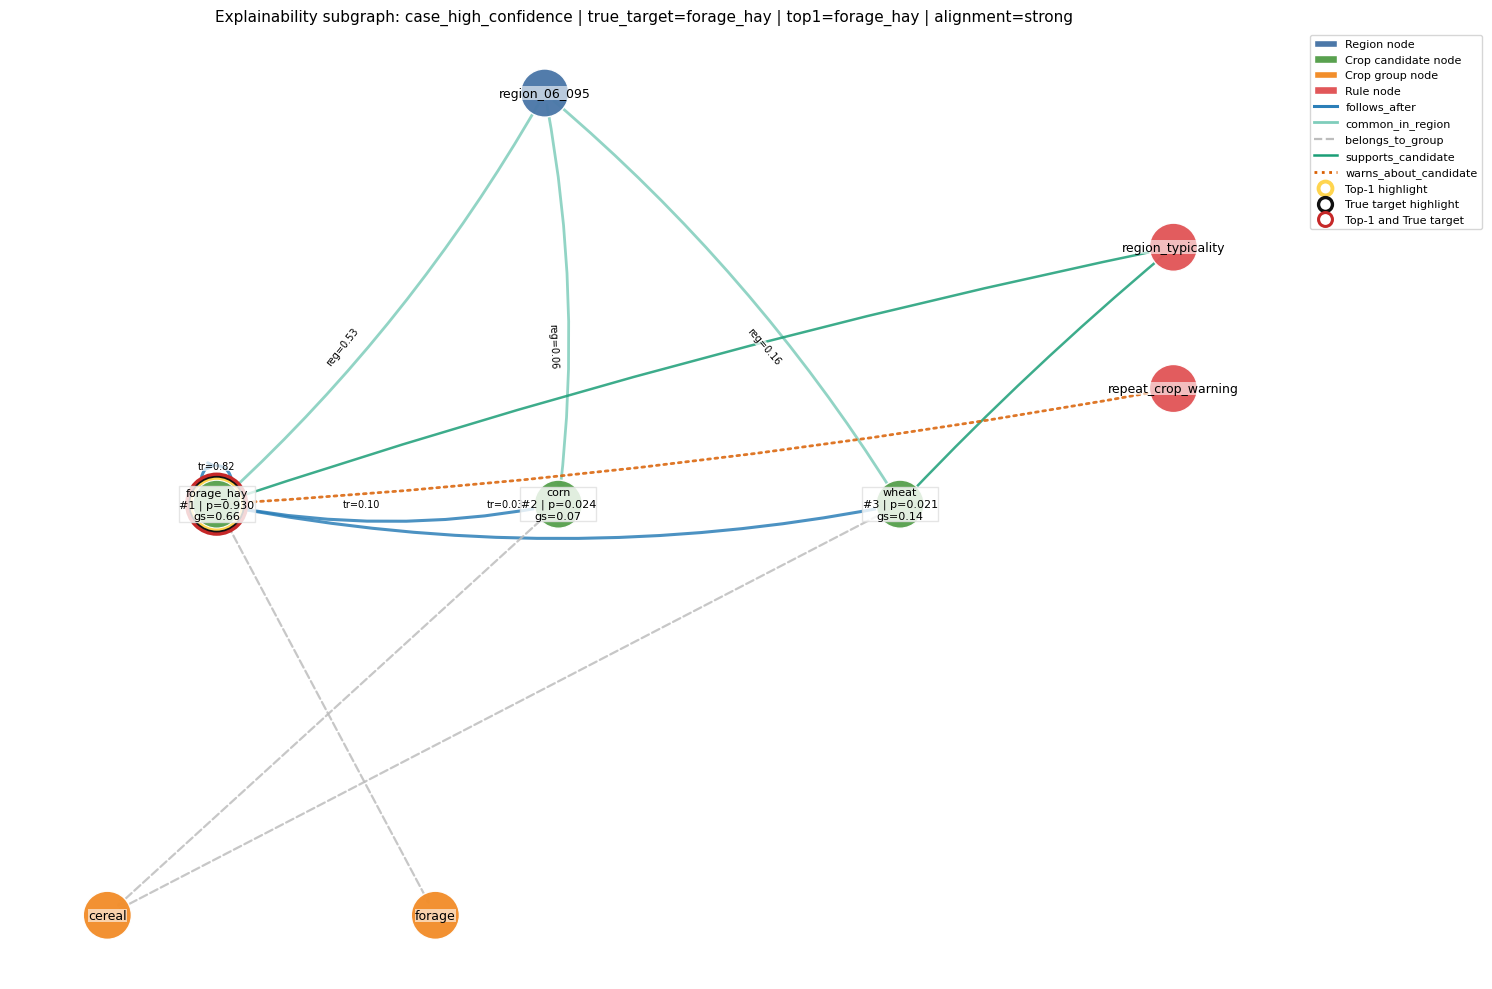

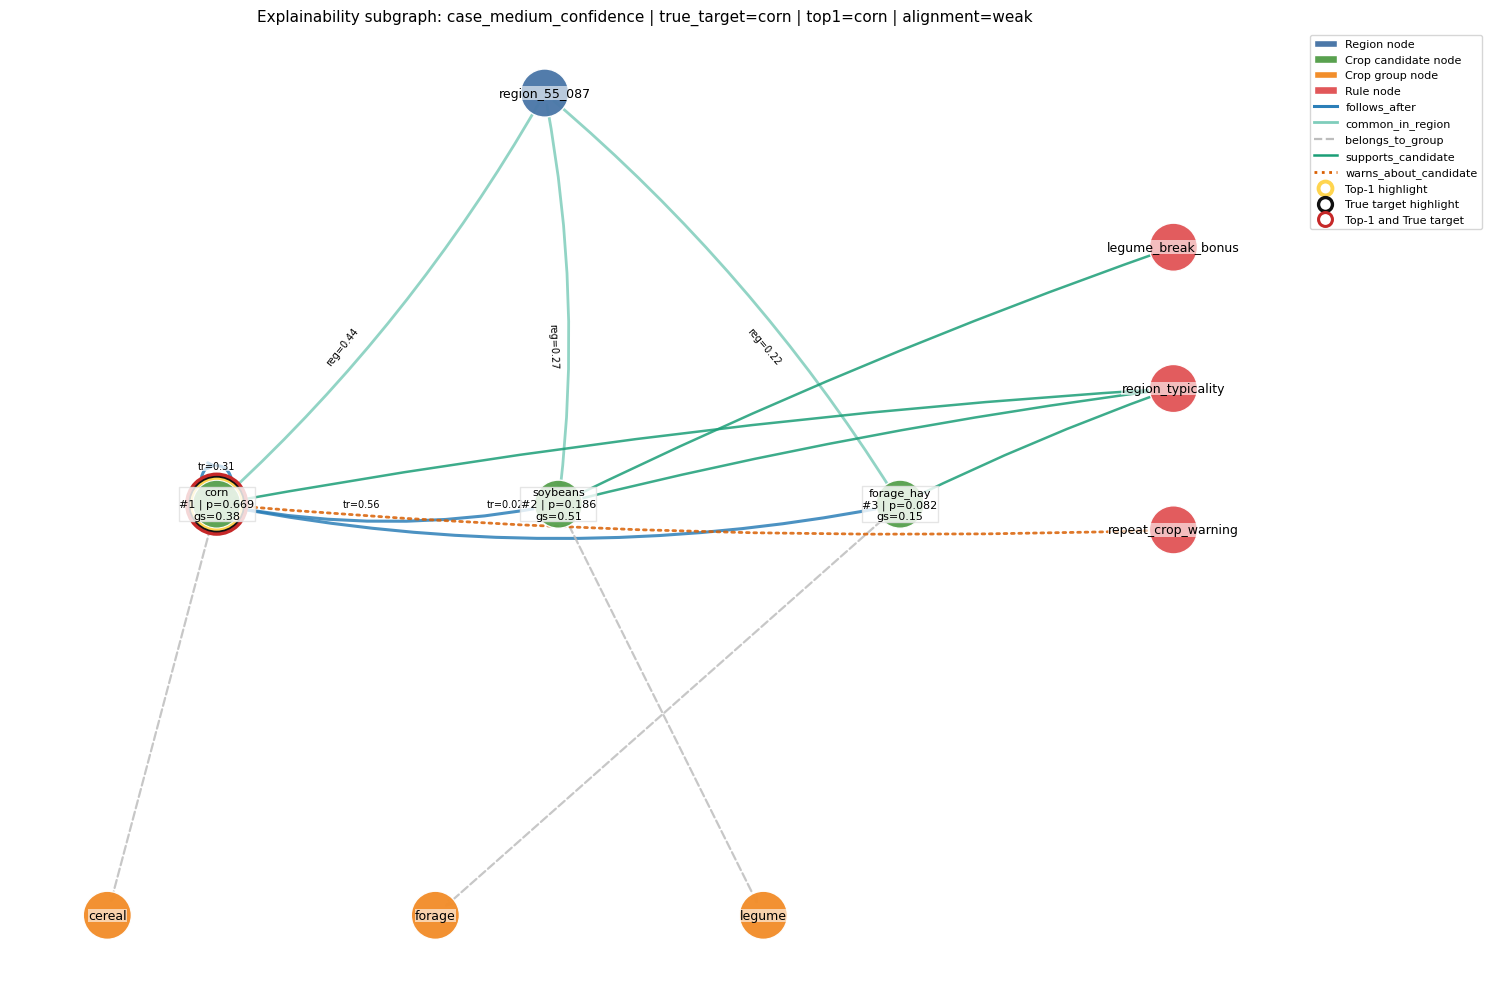

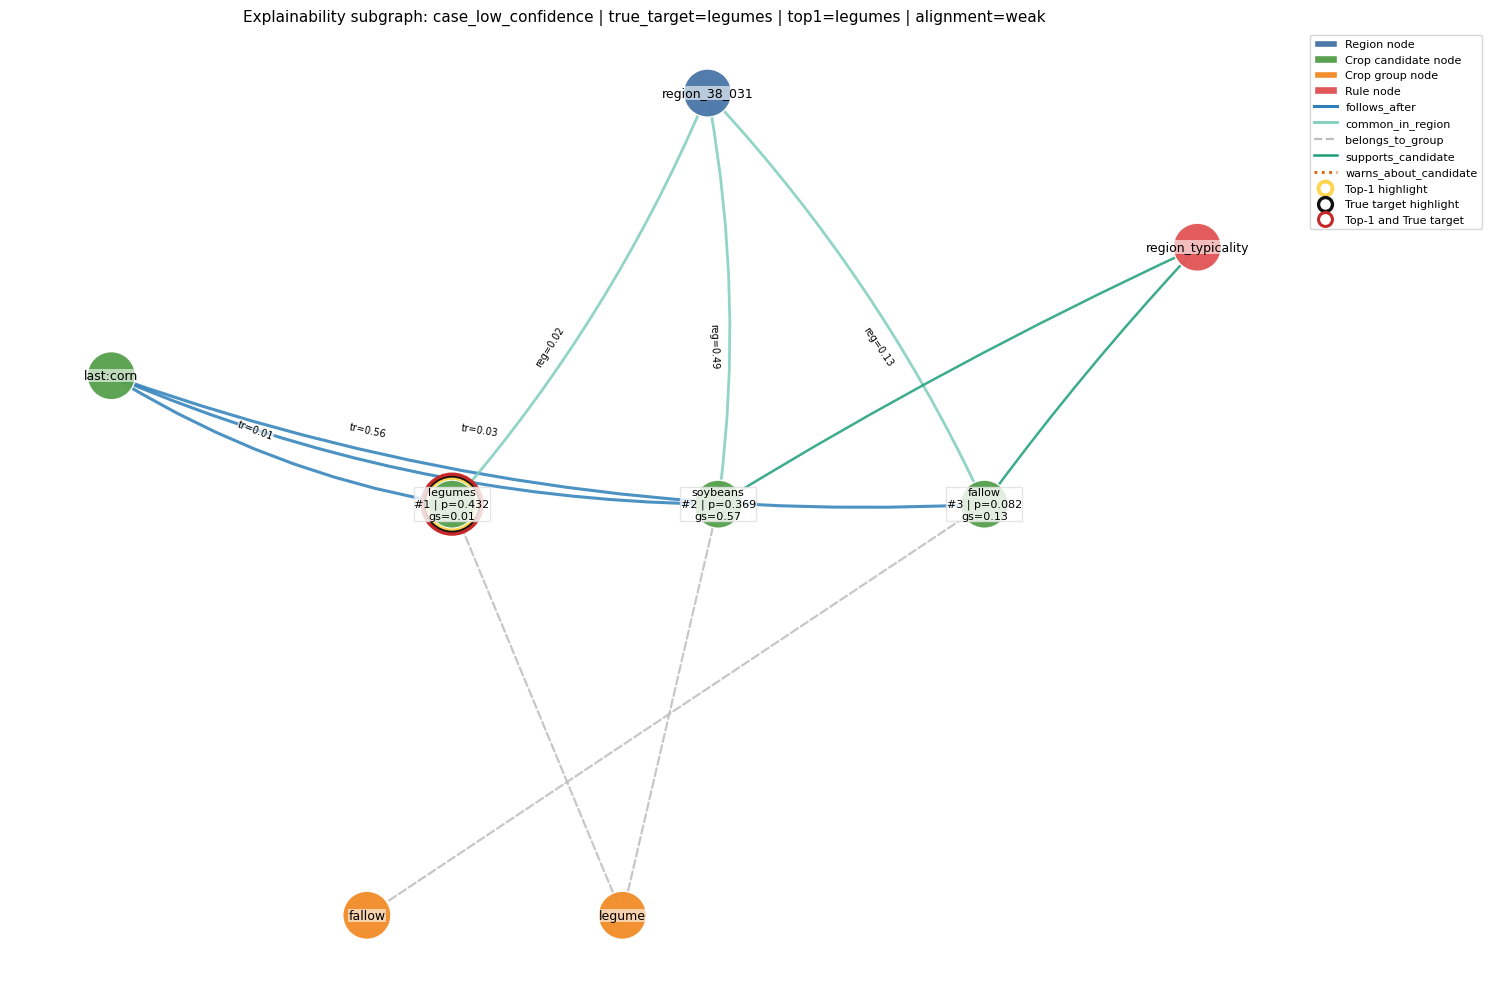

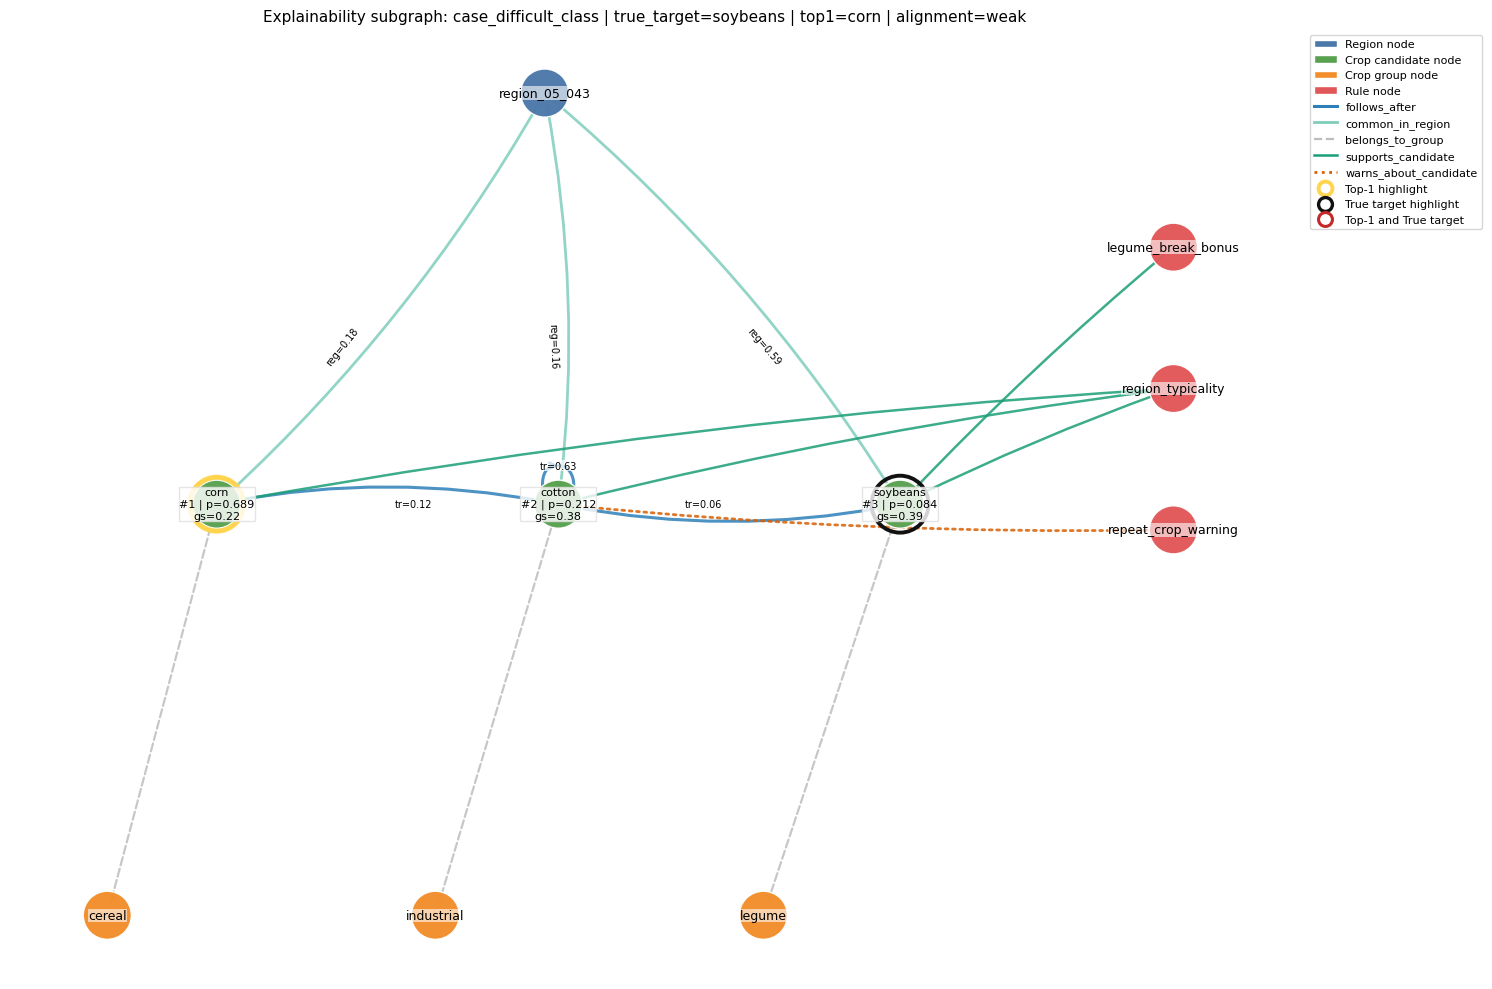

,case_label,figure_path,top1_graph_alignment
0,case_high_confidence,C:\Users\Dmitry\code-projects\diploma-crop-rot...,strong
1,case_medium_confidence,C:\Users\Dmitry\code-projects\diploma-crop-rot...,weak
2,case_low_confidence,C:\Users\Dmitry\code-projects\diploma-crop-rot...,weak
3,case_difficult_class,C:\Users\Dmitry\code-projects\diploma-crop-rot...,weak


In [36]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def draw_case_subgraph_layered(case, save_path):
    sample_row = case["sample_row"]
    cdf = case["candidate_explanations_df"]

    G = nx.DiGraph()
    region_id = make_region_id(sample_row.get("STATEFIPS"), sample_row.get("CNTYFIPS"))
    last_crop = str(sample_row.get("history_3"))
    last_crop_id = f"crop_{last_crop}"
    true_target = str(sample_row.get("target"))
    top1_candidate = str(cdf.loc[cdf["is_model_top1"], "candidate"].iloc[0]) if not cdf.empty else None

    G.add_node(region_id, node_type="Region", label=region_id)
    G.add_node(last_crop_id, node_type="Crop", label=f"last:{last_crop}")

    for r in cdf.itertuples(index=False):
        cand = str(r.candidate)
        cand_id = f"crop_{cand}"
        group_id = f"group_{r.crop_group}"
        cand_label = f"{cand}\n#{int(r.candidate_rank)} | p={float(r.score):.3f}\ngs={float(r.graph_support_score):.2f}"

        G.add_node(
            cand_id,
            node_type="Crop",
            label=cand_label,
            is_candidate=True,
            is_top1=bool(r.is_model_top1),
            is_true_target=bool(r.is_true_target),
        )
        G.add_node(group_id, node_type="CropGroup", label=str(r.crop_group))

        G.add_edge(cand_id, group_id, edge_type="belongs_to_group", weight=1.0)

        if r.transition_prob is not None:
            G.add_edge(last_crop_id, cand_id, edge_type="follows_after", weight=float(r.transition_prob))
        if r.region_share is not None:
            G.add_edge(region_id, cand_id, edge_type="common_in_region", weight=float(r.region_share))

        for flag in (r.support_flags if isinstance(r.support_flags, list) else []):
            rule_node = f"rule_{flag}"
            G.add_node(rule_node, node_type="Rule", label=flag)
            G.add_edge(rule_node, cand_id, edge_type="supports_candidate", weight=1.0)

        for flag in (r.warning_flags if isinstance(r.warning_flags, list) else []):
            rule_node = f"rule_{flag}"
            G.add_node(rule_node, node_type="Rule", label=flag)
            G.add_edge(rule_node, cand_id, edge_type="warns_about_candidate", weight=1.0)

    pos = {}
    pos[region_id] = (0.0, 2.0)
    pos[last_crop_id] = (-2.8, 0.9)

    candidate_nodes = [f"crop_{str(c)}" for c in cdf["candidate"].astype(str).tolist()]
    for i, node in enumerate(candidate_nodes):
        pos[node] = (-1.2 + i * 1.25, 0.4)

    group_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("node_type") == "CropGroup"])
    for i, node in enumerate(group_nodes):
        pos[node] = (-1.6 + i * 1.2, -1.2)

    rule_nodes = sorted([n for n, d in G.nodes(data=True) if d.get("node_type") == "Rule"])
    for i, node in enumerate(rule_nodes):
        pos[node] = (2.3, 1.4 - i * 0.55)

    plt.figure(figsize=(15, 10))

    nodelist = list(G.nodes())
    node_colors = []
    labels = {}

    for n, d in G.nodes(data=True):
        labels[n] = d.get("label", n)
        ntype = d.get("node_type", "Other")
        if ntype == "Region":
            node_colors.append("#4C78A8")
        elif ntype == "Crop":
            node_colors.append("#59A14F")
        elif ntype == "CropGroup":
            node_colors.append("#F28E2B")
        elif ntype == "Rule":
            node_colors.append("#E15759")
        else:
            node_colors.append("#BDBDBD")

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodelist,
        node_color=node_colors,
        node_size=1200,
        edgecolors="#FFFFFF",
        linewidths=1.0,
        alpha=0.97,
    )

    # Draw labels in two passes for better readability.
    non_candidate_labels = {
        n: lbl
        for n, lbl in labels.items()
        if n not in set(candidate_nodes)
    }
    candidate_labels = {
        n: labels[n]
        for n in candidate_nodes
        if n in labels
    }

    nx.draw_networkx_labels(
        G, pos, labels=non_candidate_labels, font_size=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.60, "pad": 0.2}
    )
    nx.draw_networkx_labels(
        G, pos, labels=candidate_labels, font_size=8,
        bbox={"facecolor": "white", "edgecolor": "#E0E0E0", "alpha": 0.82, "pad": 0.25}
    )

    top1_nodes = [n for n, d in G.nodes(data=True) if d.get("is_top1", False)]
    true_nodes = [n for n, d in G.nodes(data=True) if d.get("is_true_target", False)]
    both_nodes = [n for n in top1_nodes if n in set(true_nodes)]

    if top1_nodes:
        nx.draw_networkx_nodes(
            G, pos, nodelist=top1_nodes, node_color="none", node_size=1500,
            edgecolors="#FFD54F", linewidths=3.6
        )
    if true_nodes:
        nx.draw_networkx_nodes(
            G, pos, nodelist=true_nodes, node_color="none", node_size=1680,
            edgecolors="#111111", linewidths=2.8
        )
    if both_nodes:
        nx.draw_networkx_nodes(
            G, pos, nodelist=both_nodes, node_color="none", node_size=1860,
            edgecolors="#C62828", linewidths=2.4
        )

    edge_groups = {
        "follows_after": {"color": "#2C7FB8", "style": "solid", "width": 2.2, "connectionstyle": "arc3,rad=0.10"},
        "common_in_region": {"color": "#7FCDBB", "style": "solid", "width": 2.0, "connectionstyle": "arc3,rad=-0.08"},
        "belongs_to_group": {"color": "#BDBDBD", "style": "dashed", "width": 1.6, "connectionstyle": "arc3,rad=0.0"},
        "supports_candidate": {"color": "#1B9E77", "style": "solid", "width": 1.8, "connectionstyle": "arc3,rad=0.03"},
        "warns_about_candidate": {"color": "#D95F02", "style": "dotted", "width": 2.0, "connectionstyle": "arc3,rad=-0.03"},
    }

    for edge_type, style in edge_groups.items():
        edgelist = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == edge_type]
        if edgelist:
            nx.draw_networkx_edges(
                G, pos, edgelist=edgelist, arrows=True, arrowstyle="->",
                edge_color=style["color"], style=style["style"], width=style["width"], alpha=0.85,
                connectionstyle=style["connectionstyle"]
            )

    follows_labels = {}
    region_labels = {}
    for u, v, d in G.edges(data=True):
        et = d.get("edge_type", "")
        w = d.get("weight")
        if w is None:
            continue
        if et == "follows_after":
            follows_labels[(u, v)] = f"tr={float(w):.2f}"
        elif et == "common_in_region":
            region_labels[(u, v)] = f"reg={float(w):.2f}"

    label_box = {"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 0.15}
    if follows_labels:
        nx.draw_networkx_edge_labels(
            G, pos, edge_labels=follows_labels, font_size=7, label_pos=0.42,
            bbox=label_box, rotate=True
        )
    if region_labels:
        nx.draw_networkx_edge_labels(
            G, pos, edge_labels=region_labels, font_size=7, label_pos=0.62,
            bbox=label_box, rotate=True
        )

    legend_handles = [
        Patch(facecolor="#4C78A8", edgecolor="#FFFFFF", label="Region node"),
        Patch(facecolor="#59A14F", edgecolor="#FFFFFF", label="Crop candidate node"),
        Patch(facecolor="#F28E2B", edgecolor="#FFFFFF", label="Crop group node"),
        Patch(facecolor="#E15759", edgecolor="#FFFFFF", label="Rule node"),
        Line2D([0], [0], color="#2C7FB8", lw=2.2, linestyle="solid", label="follows_after"),
        Line2D([0], [0], color="#7FCDBB", lw=2.0, linestyle="solid", label="common_in_region"),
        Line2D([0], [0], color="#BDBDBD", lw=1.6, linestyle="--", label="belongs_to_group"),
        Line2D([0], [0], color="#1B9E77", lw=1.8, linestyle="solid", label="supports_candidate"),
        Line2D([0], [0], color="#D95F02", lw=2.0, linestyle=":", label="warns_about_candidate"),
        Line2D([0], [0], marker="o", markersize=10, markerfacecolor="white", markeredgecolor="#FFD54F", markeredgewidth=2.8, lw=0, label="Top-1 highlight"),
        Line2D([0], [0], marker="o", markersize=10, markerfacecolor="white", markeredgecolor="#111111", markeredgewidth=2.4, lw=0, label="True target highlight"),
        Line2D([0], [0], marker="o", markersize=10, markerfacecolor="white", markeredgecolor="#C62828", markeredgewidth=2.2, lw=0, label="Top-1 and True target"),
    ]
    plt.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True, fontsize=8)

    plt.title(
        f"Explainability subgraph: {case['label']} | true_target={true_target} | top1={top1_candidate} | alignment={case['top1_graph_alignment']}",
        fontsize=11,
    )
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

figure_rows = []
for case in case_studies[:4]:
    fig_path = FIGURES_DIR / f"{case['label']}.png"
    draw_case_subgraph_layered(case, fig_path)
    figure_rows.append({
        "case_label": case["label"],
        "figure_path": str(fig_path),
        "top1_graph_alignment": case["top1_graph_alignment"],
    })

figures_df = pd.DataFrame(figure_rows)
display(figures_df)

## 13) Final summary

In [22]:
case_explanations_rows = []
for case in case_studies:
    tmp = case["candidate_explanations_df"].copy()
    tmp.insert(0, "case_label", case["label"])
    tmp.insert(1, "case_index", case["index"])
    tmp.insert(2, "top1_graph_alignment", case["top1_graph_alignment"])
    tmp.insert(3, "case_interpretation", case["case_interpretation"])
    case_explanations_rows.append(tmp)

case_explanations_df = pd.concat(case_explanations_rows, ignore_index=True) if case_explanations_rows else pd.DataFrame()
case_explanations_df.to_csv(RESULTS_DIR / "case_explanations.csv", index=False)
case_summary_df.to_csv(RESULTS_DIR / "case_summary.csv", index=False)

run_meta = {
    "active_model": active_model,
    "model_path": str(model_path),
    "meta_path": str(meta_path),
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "nodes_count": int(len(nodes_df)),
    "edges_count": int(len(edges_df)),
    "rules_count": int(len(rules_df)),
    "cases_count": int(len(case_studies)),
    "figures_count": int(len(figures_df)),
    "alignment_distribution": case_summary_df["top1_graph_alignment"].value_counts(dropna=False).to_dict() if not case_summary_df.empty else {},
}
with open(RESULTS_DIR / "run_meta.json", "w", encoding="utf-8") as f:
    json.dump(run_meta, f, ensure_ascii=False, indent=2)

final_overview_df = pd.DataFrame([
    {"artifact": "kg_nodes.csv", "rows": len(nodes_df)},
    {"artifact": "kg_edges.csv", "rows": len(edges_df)},
    {"artifact": "kg_rules.csv", "rows": len(rules_df)},
    {"artifact": "case_explanations.csv", "rows": len(case_explanations_df)},
    {"artifact": "case_summary.csv", "rows": len(case_summary_df)},
    {"artifact": "figures/*.png", "rows": len(figures_df)},
])

print("Knowledge graph explainability artifacts are ready:", RESULTS_DIR)
print("CatBoost is the predictive core; KG + rules provide candidate-level semantic support/warning interpretation for shortlist alternatives.")
print("If a graph-supported alternative is stronger than model top-1, it is treated as a useful shortlist insight, not as a model-vs-graph error.")
display(final_overview_df)

Knowledge graph explainability artifacts are ready: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\knowledge_graph_explainability
CatBoost is the predictive core; KG + rules provide candidate-level semantic support/warning interpretation for shortlist alternatives.
If a graph-supported alternative is stronger than model top-1, it is treated as a useful shortlist insight, not as a model-vs-graph error.


,artifact,rows
0,kg_nodes.csv,2827
1,kg_edges.csv,18154
2,kg_rules.csv,5
3,case_explanations.csv,12
4,case_summary.csv,4
5,figures/*.png,4
